In [2]:
# Cell 1: Add project root to sys.path
import sys
import os

# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

print(sys.path)

# Cell 2: Import your module
from src.utils.easy_llm import load_chat_model

# Cell 3: Use your module
# my_model = load_chat_model()
# print(my_model)


['c:\\Users\\fahp\\Documents\\Training_workspace\\python for data science\\langraph\\Langgraph-notes\\langraph_assistant', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\python313.zip', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\DLLs', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\Lib', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph', '', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\Lib\\site-packages', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\Lib\\site-packages\\win32', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\fahp\\AppData\\Local\\anaconda3\\envs\\lang_graph\\Lib\\site-packages\\Pythonwin']


In [8]:
# Code Generated by Sidekick is for learning and experimentation purposes only.
import asyncio
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI

# 1. Set up the LLM and prompt
llm = load_chat_model(model_name="google")
prompt = ChatPromptTemplate([("human", "Write a concise summary of the following: {context}")])
chain = prompt | llm | StrOutputParser()

# 2. Define callback functions
def on_start(inputs, config):
    print("Chain started with input:", inputs)

def on_end(outputs, config):
    print("Chain ended with output:", outputs)

def on_error(error, config):
    print("Chain encountered an error:", error)

# 3. Create a RunnableConfig with callbacks
config = RunnableConfig(callbacks={
    "on_start": on_start,
    "on_end": on_end,
    "on_error": on_error
})




In [11]:

summary = await chain.ainvoke({"context": "Apples are red."}, config)
print("Final summary:", summary)



AttributeError: 'dict' object has no attribute 'parent_run_id'

In [ ]:
import operator
from typing import List, Literal, TypedDict

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.constants import Send
from langgraph.graph import END, START, StateGraph

llm = load_chat_model(model_name="google")

# Initial summary
summarize_prompt = ChatPromptTemplate(
    [
        ("human", "Write a concise summary of the following: {context}"),
    ]
)
initial_summary_chain = summarize_prompt | llm | StrOutputParser()

# Refining the summary with new docs
refine_template = """
Produce a final summary.

Existing summary up to this point:
{existing_answer}

New context:
------------
{context}
------------

Given the new context, refine the original summary.
"""
refine_prompt = ChatPromptTemplate([("human", refine_template)])

refine_summary_chain = refine_prompt | llm | StrOutputParser()


# For LangGraph, we will define the state of the graph to hold the query,
# destination, and final answer.
class State(TypedDict):
    contents: List[str]
    index: int
    summary: str


# We define functions for each node, including a node that generates
# the initial summary:
async def generate_initial_summary(state: State, config: RunnableConfig):
    summary = await initial_summary_chain.ainvoke(
        state["contents"][0],
        config,
    )
    return {"summary": summary, "index": 1}


# And a node that refines the summary based on the next document
async def refine_summary(state: State, config: RunnableConfig):
    content = state["contents"][state["index"]]
    summary = await refine_summary_chain.ainvoke(
        {"existing_answer": state["summary"], "context": content},
        config,
    )

    return {"summary": summary, "index": state["index"] + 1}


# Here we implement logic to either exit the application or refine
# the summary.
def should_refine(state: State) -> Literal["refine_summary", END]:
    if state["index"] >= len(state["contents"]):
        return END
    else:
        return "refine_summary"


graph = StateGraph(State)
graph.add_node("generate_initial_summary", generate_initial_summary)
graph.add_node("refine_summary", refine_summary)

graph.add_edge(START, "generate_initial_summary")
graph.add_conditional_edges("generate_initial_summary", should_refine)
graph.add_conditional_edges("refine_summary", should_refine)
app = graph.compile()

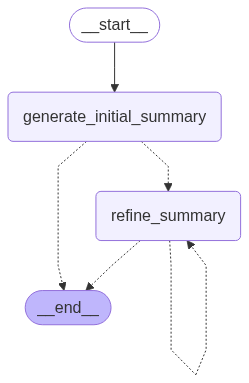

In [16]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [21]:
from langchain_core.documents import Document

documents = [
    Document(page_content="Apples are red", metadata={"title": "apple_book"}),
    Document(page_content="Blueberries are blue", metadata={"title": "blueberry_book"}),
    Document(page_content="Bananas are yelow", metadata={"title": "banana_book"}),
]

In [22]:
async for step in app.astream(
    {"contents": [doc.page_content for doc in documents]},
    stream_mode="values",
):
    if summary := step.get("summary"):
        print(summary)

{'metadata': {'langgraph_step': 1, 'langgraph_node': 'generate_initial_summary', 'langgraph_triggers': ('branch:to:generate_initial_summary',), 'langgraph_path': ('__pregel_pull', 'generate_initial_summary'), 'langgraph_checkpoint_ns': 'generate_initial_summary:0984d697-ece5-147e-2662-3f0a8aa9e9ed'}, 'configurable': {'__pregel_task_id': '0984d697-ece5-147e-2662-3f0a8aa9e9ed', '__pregel_send': functools.partial(<function local_write at 0x000001546C0DE5C0>, <built-in method extend of collections.deque object at 0x0000015410F6FA60>, ('__start__', 'generate_initial_summary', 'refine_summary')), '__pregel_read': functools.partial(<function local_read at 0x000001546C0DE520>, {'contents': <langgraph.channels.last_value.LastValue object at 0x0000015410E18640>, 'index': <langgraph.channels.last_value.LastValue object at 0x0000015410E1BD00>, 'summary': <langgraph.channels.last_value.LastValue object at 0x0000015410E18B40>, '__start__': <langgraph.channels.ephemeral_value.EphemeralValue object at

In [23]:
async for event in app.astream_events(
    {"contents": [doc.page_content for doc in documents]}, version="v2"
):
    kind = event["event"]
    if kind == "on_chat_model_stream":
        content = event["data"]["chunk"].content
        if content:
            print(content, end="|")
    elif kind == "on_chat_model_end":
        print("\n\n")

{'callbacks': <langchain_core.callbacks.manager.AsyncCallbackManager object at 0x0000015410A23BD0>, 'metadata': {'langgraph_step': 1, 'langgraph_node': 'generate_initial_summary', 'langgraph_triggers': ('branch:to:generate_initial_summary',), 'langgraph_path': ('__pregel_pull', 'generate_initial_summary'), 'langgraph_checkpoint_ns': 'generate_initial_summary:b51ec55e-fa7b-953a-9bd3-2301a5e57ead'}, 'configurable': {'__pregel_task_id': 'b51ec55e-fa7b-953a-9bd3-2301a5e57ead', '__pregel_send': functools.partial(<function local_write at 0x000001546C0DE5C0>, <built-in method extend of collections.deque object at 0x00000154080A8E50>, ('__start__', 'generate_initial_summary', 'refine_summary')), '__pregel_read': functools.partial(<function local_read at 0x000001546C0DE520>, {'contents': <langgraph.channels.last_value.LastValue object at 0x0000015408093280>, 'index': <langgraph.channels.last_value.LastValue object at 0x0000015408090C00>, 'summary': <langgraph.channels.last_value.LastValue objec